# Install Dependencies

In [166]:
%pip install -q \
    langchain langchain-groq langchain-community \
    langchain-huggingface langchain-text-splitters \
    langgraph chromadb sentence-transformers \
    pypdf requests python-dotenv rich pandas

print("Cell 1: Packages installed")

Cell 1: Packages installed


# API Key Setup

In [167]:
import os
from dotenv import load_dotenv

from google.colab import userdata
os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
print("Loaded from Colab Secrets")

Loaded from Colab Secrets


---
## All Imports

In [168]:
import os, json, csv, sqlite3, logging, time, warnings, sys, shutil
import requests
from pathlib import Path
from datetime import datetime
from collections import Counter, defaultdict
from typing import Annotated, Sequence, TypedDict, Literal, Optional, Dict, List, Any
from langchain_core.messages import (
    BaseMessage, HumanMessage, AIMessage, SystemMessage, ToolMessage
)
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_core.tools import tool
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from IPython.display import Image, display
from rich.console import Console
from rich.panel import Panel
from rich.table import Table
import pandas as pd
warnings.filterwarnings('ignore')

console = Console()
logging.basicConfig(level=logging.WARNING,
                    format='%(asctime)s | %(levelname)s | %(message)s')
logger = logging.getLogger("CeaseDesist")

print("All imports ready")

All imports ready — proceed to Cell 4


---
## Configuration

In [ ]:
IS_COLAB = 'google.colab' in sys.modules
BASE     = "/content" if IS_COLAB else "."
print(f"Environment : {'Google Colab' if IS_COLAB else 'VS Code / local Jupyter'}")
print(f"Base path   : {BASE}")

CONFIG = {
    "groq_model"           : "qwen/qwen3-32b",
    "temperature"          : 0.0,
    "max_tokens"           : 2000,

    "embedding_model"      : "sentence-transformers/all-MiniLM-L6-v2",

    "chunk_size"           : 800,
    "chunk_overlap"        : 150,
    "retrieval_k"          : 3,

    "confidence_threshold" : 0.75,

    "github_repo"          : "jayyanar/agentic-ai-training",
    "github_branch"        : "main",
    "github_pdfs_path"     : "day5/capstone-project/data/pdfs",

    "intake_folder"        : f"{BASE}/data/pdfs",
    "chroma_db_path"       : f"{BASE}/chroma_db",
    "sqlite_db_path"       : f"{BASE}/cease_desist.db",
    "archive_csv_path"     : f"{BASE}/irrelevant_archive.csv",
    "audit_log_path"       : f"{BASE}/audit_log.csv",
    "hitl_queue_path"      : f"{BASE}/hitl_queue.csv",
    "summary_report_path"  : f"{BASE}/categorisation_summary.csv",
}

for d in [CONFIG["intake_folder"], CONFIG["chroma_db_path"]]:
    Path(d).mkdir(parents=True, exist_ok=True)

CEASE      = "cease"        # → SQLite database
UNCERTAIN  = "uncertain"    # → HITL review
IRRELEVANT = "irrelevant"   # → CSV archive

CLASS_COLOR = {CEASE: "bold red", UNCERTAIN: "bold yellow", IRRELEVANT: "bold green"}
CLASS_EMOJI = {CEASE: "🔴", UNCERTAIN: "🟡", IRRELEVANT: "🟢"}

console.print(Panel(
    f"[bold]LLM     :[/bold] [cyan]{CONFIG['groq_model']}[/cyan]\n"
    f"[bold]Intake  :[/bold] [cyan]{CONFIG['intake_folder']}[/cyan]\n"
    f"[bold]GitHub  :[/bold] [cyan]github.com/{CONFIG['github_repo']}/{CONFIG['github_pdfs_path']}[/cyan]",
    title="[bold]Configuration"
))

## Download PDFs from GitHub Intake Folder

In [170]:
def download_pdfs_from_github() -> List[str]:
    """
    Download all PDFs from the GitHub intake folder.
    Returns list of local file paths that were downloaded.
    """
    repo   = CONFIG["github_repo"]
    branch = CONFIG["github_branch"]
    path   = CONFIG["github_pdfs_path"]
    dest   = Path(CONFIG["intake_folder"])

    api_url = f"https://api.github.com/repos/{repo}/contents/{path}?ref={branch}"
    console.print(f"[bold blue] Fetching file list from GitHub API...[/bold blue]")
    console.print(f"   URL: {api_url}")

    try:
        # Step 1: Get file listing via GitHub Contents API
        resp = requests.get(api_url, timeout=15,
                            headers={"Accept": "application/vnd.github.v3+json"})
        resp.raise_for_status()
        files = resp.json()

        if not isinstance(files, list):
            raise ValueError(f"Unexpected response: {str(files)[:200]}")

        # Step 2: Filter to PDFs only
        pdf_files = [f for f in files
                     if f.get("type") == "file" and f["name"].lower().endswith(".pdf")]

        if not pdf_files:
            console.print("No PDF files found in GitHub folder")
            return []

        console.print(f"Found {len(pdf_files)} PDF(s) to download")
        downloaded = []

        # Step 3: Download each PDF
        for file_info in pdf_files:
            fname       = file_info["name"]
            local_path  = dest / fname
            download_url = file_info["download_url"]

            # Skip if already downloaded (avoids re-downloading on re-runs)
            if local_path.exists() and local_path.stat().st_size > 0:
                console.print(f"-- Already exists: {fname}")
                downloaded.append(str(local_path))
                continue

            pdf_resp = requests.get(download_url, timeout=30)
            pdf_resp.raise_for_status()
            local_path.write_bytes(pdf_resp.content)
            size_kb = local_path.stat().st_size // 1024
            console.print(f"   Downloaded: {fname} ({size_kb} KB)")
            downloaded.append(str(local_path))

        return downloaded

    except Exception as e:
        console.print(f" GitHub download failed: {e}")
        console.print("   Falling back to generated sample PDFs...")
        return []


def generate_sample_pdfs() -> List[str]:
    """
    Generate 5 realistic sample PDFs using ReportLab.
    Used as fallback when GitHub is unavailable.
    Covers all 3 categories: cease, uncertain, irrelevant.
    """
    from reportlab.lib.pagesizes import A4
    from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
    from reportlab.lib.units import cm
    from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer
    from reportlab.lib.enums import TA_CENTER

    def make_pdf(path: str, lines: list, title: str = "") -> None:
        doc    = SimpleDocTemplate(path, pagesize=A4,
                                   leftMargin=2*cm, rightMargin=2*cm,
                                   topMargin=2*cm, bottomMargin=2*cm)
        styles = getSampleStyleSheet()
        ts = ParagraphStyle('T', parent=styles['Heading1'],
                            fontSize=13, spaceAfter=16, alignment=TA_CENTER)
        bs = ParagraphStyle('B', parent=styles['Normal'],
                            fontSize=11, spaceAfter=7, leading=15)
        story = []
        if title:
            story += [Paragraph(title, ts), Spacer(1, 0.4*cm)]
        for line in lines:
            story.append(Paragraph(line, bs) if line.strip() else Spacer(1, 0.25*cm))
        doc.build(story)

    dest   = Path(CONFIG["intake_folder"])
    docs   = [
        ("cease_001.pdf",
         ["Date: November 15, 2024",
          "To: Customer Communications Dept  |  From: John Mitchell  |  Account: ACC-2024-8821",
          "",
          "I formally demand your company IMMEDIATELY CEASE AND DESIST all forms of direct "
          "communication — calls, SMS, emails, postal mail. Continued contact is a legal violation.",
          "",
          "Confirm compliance within 5 business days.",
          "John Mitchell | john.mitchell@email.com | (217) 555-0143"],
         "CEASE AND DESIST NOTICE"),

        ("cease_002.pdf",
         ["Date: December 3, 2024",
          "Law Office of Sarah Chen, Esq. — behalf of: Ms. Patricia Nguyen (Acct: PN-90234)",
          "",
          "This firm formally DEMANDS your organisation immediately cease and desist from "
          "contacting our client through any channel. Violation of TCPA + CAN-SPAM Act.",
          "",
          "Stop ALL comms, remove from all databases, confirm within 3 days or face litigation.",
          "Sarah Chen, Esq. | Chen Legal Group, Chicago IL"],
         "LEGAL CEASE & DESIST DEMAND"),

        ("uncertain_003.pdf",
         ["Date: November 28, 2024",
          "From: Robert Kim  |  Account: RK-55102",
          "",
          "I have been receiving too many messages. Please reduce the frequency — "
          "just the important stuff, not promotional emails.",
          "",
          "I am NOT saying stop completely — just opt me out of marketing but keep alerts.",
          "Robert Kim"],
         "Communication Preference Request"),

        ("irrelevant_004.pdf",
         ["SERVICE AGREEMENT — ABC Tech Services & XYZ Corporation",
          "Services: Monthly server checks, 24/7 helpdesk, quarterly security audits.",
          "Duration: Jan–Dec 2025.  Contract Value: $48,000 USD.",
          "Governed by the laws of the State of Illinois."],
         "Annual IT Service Agreement"),

        ("irrelevant_005.pdf",
         ["From: Maria Gonzalez | Customer since March 2023",
          "",
          "I recently purchased your Premium Plan. Onboarding was smooth and the dashboard "
          "is intuitive. The mobile app could use better push-notification management. "
          "Your support team was excellent during setup.",
          "Best regards, Maria Gonzalez"],
         "Customer Satisfaction Feedback"),
    ]

    paths = []
    for fname, lines, title in docs:
        p = dest / fname
        make_pdf(str(p), lines, title)
        paths.append(str(p))
        console.print(f" Created sample: {fname}")
    return paths

# ── Run the downloader ─────────────────────────────────────────────────
intake_pdf_paths = download_pdfs_from_github()

if not intake_pdf_paths:
    console.print("Generating sample PDFs (GitHub fallback)...")
    try:
        %pip install -q reportlab
        intake_pdf_paths = generate_sample_pdfs()
    except Exception as e:
        console.print(f"Sample PDF generation failed: {e}")

# Also scan the folder in case it had pre-existing PDFs
all_intake_pdfs = sorted(Path(CONFIG["intake_folder"]).glob("*.pdf"))

console.print(Panel(
    "\n".join(f" {p.name}" for p in all_intake_pdfs),
    title=f"[bold green] {len(all_intake_pdfs)} PDFs ready in {CONFIG['intake_folder']}"
))

 Fetching file list from GitHub API...

URL: https://api.github.com/repos/jayyanar/agentic-ai-training/contents/day5/capstone-project/data/pdfs?ref=main

Found 29 PDF(s) to download

-- Already exists: 01_copyright_infringement_photography.pdf

-- Already exists: 02_trademark_infringement_tech.pdf

...

-- Already exists: notice_2.pdf

-- Already exists: notice_3.pdf

-- Already exists: notice_4.pdf

-- Already exists: notice_5.pdf

╭─────────────────────────────────────  29 PDFs ready in /content/data/pdfs ──────────────────────────────────────╮
│  01_copyright_infringement_photography.pdf                                                                      │
│  02_trademark_infringement_tech.pdf                                                                             │
│  03_trade_secret_misappropriation.pdf                                                                           │
│  04_defamation_online_review.pdf                                                                                │
│  05_patent_infringement_medical_device.pdf                                                                      │
│  06_harassment_workplace.pdf                                                                                    │
│  07_software_license_violation.pdf                                                                              │
│  08_non_compete_violation.pdf                                                                                   │
│  09_copyright_infringement_music.pdf                                                                            │
│  10_breach_of_contract_nda.pdf                                                                                  │
│  LOA2.pdf                                                                                                       │
│  LOA3.pdf                                                                                                       │
│  LOA4.pdf                                                                                                       │
│  LOA5.pdf                                                                                                       │
│  LOA6.pdf                                                                                                       │
│  LOA7.pdf                                                                                                       │
│  LOA8.pdf                                                                                                       │
│  LOA9.pdf                                                                                                       │
│  LoA1.pdf                                                                                                       │
│  bw_doc_1.pdf                                                                                                   │
│  bw_doc_2.pdf                                                                                                   │
│  bw_doc_3.pdf                                                                                                   │
│  bw_doc_4.pdf                                                                                                   │
│  bw_doc_5.pdf                                                                                                   │
│  notice_1.pdf                                                                                                   │
│  notice_2.pdf                                                                                                   │
│  notice_3.pdf                                                                                                   │
│  notice_4.pdf                                                                                                   │
│  notice_5.pdf                                                                                                   │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯


## ChromaDB + Conversational RAG

In [171]:
# ── 1. Load and chunk all intake PDFs ──────────────────────────────────
splitter   = RecursiveCharacterTextSplitter(
    chunk_size    = CONFIG["chunk_size"],
    chunk_overlap = CONFIG["chunk_overlap"],
    separators    = ["\n\n", "\n", ". ", " ", ""]
)

all_chunks = []
for p in all_intake_pdfs:
    try:
        pages = PyPDFLoader(str(p)).load()   # one Document per PDF page
        for page in pages:
            page.metadata["source_file"] = p.name
        all_chunks.extend(splitter.split_documents(pages))
    except Exception as e:
        logger.warning(f" Could not load {p.name}: {e}")

print(f" {len(all_intake_pdfs)} PDFs → {len(all_chunks)} chunks")

# ── 2. HuggingFace embeddings ──────────────────────────────────────────
print(" Loading embedding model ...")
embeddings = HuggingFaceEmbeddings(
    model_name    = CONFIG["embedding_model"],
    model_kwargs  = {"device": "cpu"},
    encode_kwargs = {"normalize_embeddings": True}
)
print(" Embeddings ready")

# ── 3. ChromaDB vector store ───────────────────────────────────────────
vectorstore = Chroma.from_documents(
    documents         = all_chunks,
    embedding         = embeddings,
    persist_directory = CONFIG["chroma_db_path"],
    collection_name   = "cease_desist_docs"
)
retriever = vectorstore.as_retriever(
    search_type   = "similarity",
    search_kwargs = {"k": CONFIG["retrieval_k"]}
)
print(f" ChromaDB: {vectorstore._collection.count()} vectors")

# ── 4. ChatGroq LLM ───────────────────────────────────────────────────
# reasoning_format="parsed" removes Qwen3's chain-of-thought XML blocks
llm = ChatGroq(
    model            = CONFIG["groq_model"],
    temperature      = CONFIG["temperature"],
    max_tokens       = CONFIG["max_tokens"],
    reasoning_format = "parsed"
)
print(f" ChatGroq: {CONFIG['groq_model']}")

# ── 5. Conversational RAG chain (Lab2_2 pattern) ──────────────────────

# 5a. Contextualisation prompt — rephrases question using chat history
contextualize_q_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "Given a chat history and the latest user question which might reference "
     "context in the chat history, formulate a standalone question that can be "
     "understood without the history. Do NOT answer — just reformulate if needed, "
     "otherwise return the question as is."),
    MessagesPlaceholder("chat_history"),   # injected at invoke-time
    ("human", "{input}"),
])

# 5b. Chain: prompt → LLM → plain string (rephrased standalone query)
contextualize_q_chain = contextualize_q_prompt | llm | StrOutputParser()

# 5c. Conditional: only contextualise when history exists
def contextualized_question(inp: dict):
    """
    If chat_history is present, return the contextualize_q_chain Runnable
    (which rephrases the query). Otherwise return the raw query string.
    RunnablePassthrough.assign() will call this and pipe the result to retriever.
    """
    if inp.get("chat_history"):
        return contextualize_q_chain
    return inp.get("input", "")

# 5d. Format retrieved documents into a readable context string
def format_docs(docs) -> str:
    if not docs:
        return "No similar documents found."
    return "\n\n".join(
        f"[Similar {i} — {d.metadata.get('source_file','?')}]:\n{d.page_content[:350]}"
        for i, d in enumerate(docs, 1)
    )

# 5e. Full RAG context chain
# RunnablePassthrough.assign(context=...) adds a 'context' key to the
# dict flowing through the pipeline without removing other keys.
RAG_CONTEXT_CHAIN = RunnablePassthrough.assign(
    context = contextualized_question | retriever | format_docs
)

print(" Conversational RAG chain ready)")

 29 PDFs → 105 chunks
 Loading embedding model ...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 Embeddings ready
 ChromaDB: 945 vectors
 ChatGroq: qwen/qwen3-32b
 Conversational RAG chain ready)


---
## LangGraph State: TypedDict, Annotated and add_messages Reducer

In [172]:
class CeaseDesistState(TypedDict):
    """
    Shared state flowing through every LangGraph node.
    Each node receives the full state and returns a partial update dict.
    """

    messages          : Annotated[Sequence[BaseMessage], add_messages]

    # Document fields
    document_path     : str           # Full path to input PDF
    document_name     : str           # Filename only
    raw_text          : str           # Text from PyPDFLoader
    processing_date   : str           # ISO timestamp

    # RAG
    rag_context       : str           # Retrieved similar chunks

    # Classification
    classification    : str           # "cease" | "uncertain" | "irrelevant"
    confidence        : float         # 0.0 – 1.0
    explanation       : str           # LLM reasoning
    extracted_details : dict          # sender, account, email, date, phrases

    # Action tracking
    action_taken      : str
    hitl_result       : Optional[str]  # Human decision (None if no HITL)
    audit_entry       : dict
    error             : Optional[str]


print("CeaseDesistState defined")

CeaseDesistState defined


## Tool Definitions with @tool

In [173]:
# Init SQLite DB (idempotent)
conn = sqlite3.connect(CONFIG["sqlite_db_path"])
conn.execute("""
    CREATE TABLE IF NOT EXISTS cease_desist_requests (
        id             INTEGER PRIMARY KEY AUTOINCREMENT,
        received_date  TEXT,  processed_date TEXT,
        document_name  TEXT NOT NULL,  sender_name TEXT,
        account_number TEXT,  sender_email TEXT,
        confidence     REAL,  explanation TEXT,
        full_text      TEXT,  extracted_json TEXT,
        created_at     TIMESTAMP DEFAULT CURRENT_TIMESTAMP
    )
""")
conn.commit(); conn.close()
print(f" SQLite DB ready: {CONFIG['sqlite_db_path']}")


@tool
def store_cease_record(
    document_name: str, received_date: str, sender_name: str,
    account_number: str, sender_email: str, confidence: float,
    explanation: str, full_text: str, extracted_json: str
) -> str:
    """
    Store a validated Cease and Desist request in the SQLite database.
    Call ONLY when classification is 'cease'.
    Creates a permanent compliance record. Returns confirmation with record ID.
    """
    try:
        conn = sqlite3.connect(CONFIG["sqlite_db_path"])
        cur  = conn.cursor()
        cur.execute("""
            INSERT INTO cease_desist_requests
            (received_date,processed_date,document_name,sender_name,
             account_number,sender_email,confidence,explanation,full_text,extracted_json)
            VALUES (?,?,?,?,?,?,?,?,?,?)
        """, (received_date, datetime.now().isoformat(), document_name,
               sender_name, account_number, sender_email, confidence,
               explanation[:500], full_text[:2000], extracted_json))
        rid = cur.lastrowid
        conn.commit(); conn.close()
        return f"SUCCESS: Cease & Desist stored as record #{rid}"
    except Exception as e:
        return f"ERROR: {e}"


@tool
def archive_irrelevant_document(
    document_name: str, received_date: str,
    confidence: float, explanation: str
) -> str:
    """
    Archive an irrelevant document to the flat CSV file.
    Call ONLY when classification is 'irrelevant'.
    Writes document name, date, confidence, and explanation to CSV.
    Returns confirmation with archive file path.
    """
    try:
        p   = Path(CONFIG["archive_csv_path"])
        hdr = not p.exists()
        with open(p, 'a', newline='', encoding='utf-8') as f:
            w = csv.DictWriter(f, fieldnames=[
                "archived_at","document_name","received_date","confidence","explanation"
            ])
            if hdr: w.writeheader()
            w.writerow({"archived_at"  : datetime.now().isoformat(),
                        "document_name": document_name,
                        "received_date": received_date,
                        "confidence"   : round(confidence, 3),
                        "explanation"  : explanation[:250]})
        return f"SUCCESS: '{document_name}' archived to {p}"
    except Exception as e:
        return f"ERROR: {e}"


ACTION_TOOLS = [store_cease_record, archive_irrelevant_document]
print(f"\n Tools defined: {[t.name for t in ACTION_TOOLS]}")

 SQLite DB ready: /content/cease_desist.db

 Tools defined: ['store_cease_record', 'archive_irrelevant_document']


# ToolNode + LLM Variants

In [174]:
action_tool_node = ToolNode(tools=ACTION_TOOLS)
llm_with_tools   = llm.bind_tools(ACTION_TOOLS)  # LLM knows tool schemas
llm_classifier   = llm                            # Plain LLM — JSON output

print(f" ToolNode    : {[t.name for t in ACTION_TOOLS]}")
print(f" llm_with_tools: tools bound")
print(f" llm_classifier: no tools (JSON output only)")

 ToolNode    : ['store_cease_record', 'archive_irrelevant_document']
 llm_with_tools: tools bound
 llm_classifier: no tools (JSON output only)


#  Agent Nodes Part 1

In [175]:
def read_document_node(state: CeaseDesistState) -> dict:
    """Node 1: Extract text from PDF with PyPDFLoader."""
    name = Path(state["document_path"]).name
    console.print(f"\n [ReadDoc] {name}")
    try:
        pages    = PyPDFLoader(state["document_path"]).load()
        raw_text = "\n\n".join(
            f"--- Page {i+1} ---\n{p.page_content}" for i, p in enumerate(pages)
        )
        if len(raw_text.strip()) < 20:
            raise ValueError("Text too short — image-only PDF?")
        console.print(f" {len(pages)} page(s), {len(raw_text)} chars")
        return {
            "raw_text"       : raw_text,
            "processing_date": datetime.now().isoformat(),
            "error"          : None,
            "messages"       : [SystemMessage(content=
                f"Started: {name} | {len(pages)} page(s) | {len(raw_text)} chars"
            )]
        }
    except Exception as e:
        err = f"ReadDoc error: {e}"
        return {"raw_text": "", "processing_date": datetime.now().isoformat(),
                "error": err, "messages": [SystemMessage(content=f"ERROR: {err}")]}


def retrieve_context_node(state: CeaseDesistState) -> dict:
    """
    Node 2: Conversational RAG — retrieve similar chunks from ChromaDB.

    Uses RAG_CONTEXT_CHAIN (the Lab2_2 pattern):
      chat_history = accumulated state.messages so far
      input        = first 800 chars of document text
      → contextualize_q_chain rephrases query using history
      → retriever searches ChromaDB
      → format_docs returns readable context string
    """
    if state.get("error"):
        return {"rag_context": "",
                "messages": [SystemMessage(content="RAG skipped.")]}

    history = list(state.get("messages", []))
    console.print(f"ChromaDB search (history: {len(history)} msgs)")
    try:
        result  = RAG_CONTEXT_CHAIN.invoke({
            "input"       : state["raw_text"][:800],
            "chat_history": history
        })
        context = result.get("context", "No similar docs found.")
        console.print(f" Context: {len(context)} chars")
        return {
            "rag_context": context,
            "messages"   : [SystemMessage(content=f"RAG context:\n{context[:500]}")]
        }
    except Exception as e:
        return {"rag_context": "",
                "messages": [SystemMessage(content=f"RAG failed: {e}")]}


# ── Classification system prompt ───────────────────────────────────────
CLASSIFIER_SYSTEM = """\
You are an expert compliance analyst specialising in Cease & Desist (C&D) communications.
Classify the document into EXACTLY ONE of:

  "cease"      — CLEAR explicit request to STOP ALL direct communications.
                 Signals: "cease and desist", "stop all contact", formal legal C&D letter.

  "uncertain"  — Possibly C&D but AMBIGUOUS: wants REDUCED (not stopped) comms,
                 unclear intent, partial opt-out, missing explicit "cease" language.

  "irrelevant" — NOT a communication cessation request:
                 contracts, invoices, feedback, general queries.

Respond ONLY with valid JSON — no markdown, no preamble:
{
  "classification": "cease" | "uncertain" | "irrelevant",
  "confidence": <float 0.0-1.0>,
  "explanation": "<one paragraph reasoning>",
  "extracted_details": {
    "sender_name": "<name or null>",
    "sender_email": "<email or null>",
    "account_number": "<account or null>",
    "document_date": "<date or null>",
    "represented_by": "<lawyer/firm or null>",
    "key_phrases": ["<phrases indicating C&D>"]
  }
}"""


def classify_document_node(state: CeaseDesistState) -> dict:
    """
    Node 3: Classify document with ChatGroq (qwen/qwen3-32b).
    Passes accumulated messages (includes RAG context) as context.
    Low confidence → auto-escalate to UNCERTAIN.
    """
    if state.get("error"):
        return {"classification": UNCERTAIN, "confidence": 0.0,
                "explanation": "Prior error.", "extracted_details": {}}

    console.print(f"[Classify] {CONFIG['groq_model']}...")

    msgs = [
        SystemMessage(content=CLASSIFIER_SYSTEM),
        *list(state.get("messages", [])),     # includes RAG context
        HumanMessage(content=
            f"Document:\n{state['raw_text'][:3000]}\n\n"
            f"Similar docs from KB:\n{state.get('rag_context','None')[:600]}"
        )
    ]

    response = llm_classifier.invoke(msgs)
    raw = response.content.strip().replace("```json","").replace("```","").strip()

    try:
        result = json.loads(raw)
    except json.JSONDecodeError:
        console.print("  JSON parse failed → UNCERTAIN")
        return {"classification": UNCERTAIN, "confidence": 0.0,
                "explanation": "JSON parse error — HITL.",
                "extracted_details": {},
                "messages": [HumanMessage(content="classify"),
                             AIMessage(content="failed — HITL")]}

    cls  = result.get("classification", UNCERTAIN)
    conf = float(result.get("confidence", 0.0))

    # Safety net: low confidence → escalate
    if conf < CONFIG["confidence_threshold"] and cls != UNCERTAIN:
        result["explanation"] = (
            f"[Auto-escalated: {conf:.2f} < {CONFIG['confidence_threshold']}] "
            + result.get("explanation", "")
        )
        cls = UNCERTAIN

    col = CLASS_COLOR.get(cls, "white")
    console.print(f"  [{col}]{cls.upper()}[/{col}] ({conf:.2f})")
    return {
        "classification"   : cls,
        "confidence"       : conf,
        "explanation"      : result.get("explanation", ""),
        "extracted_details": result.get("extracted_details", {}),
        "messages": [
            HumanMessage(content=f"Classify: {state['raw_text'][:200]}"),
            AIMessage(content=f"Classification: {cls} ({conf:.2f})")
        ]
    }


def router_node(state: CeaseDesistState) -> dict:
    """
    Node 4: Named routing node — logs routing decision to messages.
    Actual branch is decided by route_after_classification() below.
    """
    cls  = state.get("classification", UNCERTAIN)
    dest = {CEASE     : "action_agent → SQLite",
            IRRELEVANT: "action_agent → CSV",
            UNCERTAIN : "hitl_node → human review"}.get(cls, "hitl_node")
    console.print(f"[Router] {cls.upper()} → {dest}")
    return {"messages": [SystemMessage(content=f"Routing: {cls.upper()} → {dest}")]}


def route_after_classification(
    state: CeaseDesistState
) -> Literal["action_agent_node", "hitl_node"]:
    """Conditional edge function — return value must match a registered node name."""
    return "action_agent_node" \
           if state.get("classification") in [CEASE, IRRELEVANT] \
           else "hitl_node"


print(" Nodes: read_document, retrieve_context, classify_document, router_node")

 Nodes: read_document, retrieve_context, classify_document, router_node


#  Agent Nodes Part 2

In [176]:
def action_agent_node(state: CeaseDesistState) -> dict:
    """Node 5: Generate tool call (store or archive) using llm_with_tools."""
    cls   = state["classification"]
    d     = state.get("extracted_details", {})
    name  = state["document_name"]
    rdate = d.get("document_date") or state["processing_date"][:10]

    console.print(f"\n [ActionAgent] {cls.upper()}...")

    if cls == CEASE:
        instr = (
            f"'{name}' is a C&D. Call store_cease_record:\n"
            f"  document_name='{name}', received_date='{rdate}',"
            f" sender_name='{d.get('sender_name','Unknown')}',"
            f" account_number='{d.get('account_number','N/A')}',"
            f" sender_email='{d.get('sender_email','N/A')}',"
            f" confidence={state.get('confidence',0)},"
            f" explanation='{state.get('explanation','')[:200]}',"
            f" full_text='{state.get('raw_text','')[:500]}',"
            f" extracted_json='{json.dumps(d)}'"
        )
    else:
        instr = (
            f"'{name}' is irrelevant. Call archive_irrelevant_document:\n"
            f"  document_name='{name}', received_date='{rdate}',"
            f" confidence={state.get('confidence',0)},"
            f" explanation='{state.get('explanation','')[:200]}'"
        )

    resp = llm_with_tools.invoke([
        SystemMessage(content="You are an action dispatcher. Call the tool as instructed."),
        HumanMessage(content=instr)
    ])

    if resp.tool_calls:
        console.print(f" {[tc['name'] for tc in resp.tool_calls]}")
    return {"messages": [resp]}


def after_tool_node(state: CeaseDesistState) -> dict:
    """Node 6: Extract ToolMessage result from state.messages → action_taken."""
    result = "tool executed"
    for msg in reversed(list(state.get("messages", []))):
        if isinstance(msg, ToolMessage):
            result = msg.content
            break
    console.print(f" {result[:80]}")
    return {"action_taken": result}


def hitl_node(state: CeaseDesistState) -> dict:
    """
    Node 7: Human-in-the-Loop via interrupt().

    interrupt({payload}) → graph PAUSES, state saved by MemorySaver.
    Resume: app.invoke(Command(resume='cease'|'irrelevant'|'skip'),
                       config={"configurable":{"thread_id":"<same id>"}})
    interrupt() then returns the resume value and execution continues.
    """
    d = state.get("extracted_details", {})
    console.print(f"\n [HITL] Pausing for human review...")

    # Save to HITL queue CSV
    qp  = Path(CONFIG["hitl_queue_path"])
    hdr = not qp.exists()
    with open(qp, 'a', newline='', encoding='utf-8') as f:
        w = csv.DictWriter(f, fieldnames=[
            "queued_at","document_name","llm_classification",
            "confidence","explanation","sender_name","account_number"
        ])
        if hdr: w.writeheader()
        w.writerow({"queued_at"         : datetime.now().isoformat(),
                    "document_name"     : state["document_name"],
                    "llm_classification": state.get("classification","uncertain"),
                    "confidence"        : round(state.get("confidence",0),3),
                    "explanation"       : state.get("explanation","")[:200],
                    "sender_name"       : d.get("sender_name",""),
                    "account_number"    : d.get("account_number","")})

    # ── PAUSE HERE ──────────────────────────────────────────────────────
    human_decision = interrupt({
        "type"              : "human_review_required",
        "document_name"     : state["document_name"],
        "llm_classification": state.get("classification"),
        "confidence"        : state.get("confidence"),
        "explanation"       : state.get("explanation","")[:400],
        "sender_name"       : d.get("sender_name"),
        "account_number"    : d.get("account_number"),
        "document_preview"  : state.get("raw_text","")[:500],
        "resume_hint"       : "Command(resume='cease'|'irrelevant'|'skip')"
    })
    # ── RESUMES HERE ─────────────────────────────────────────────────────

    console.print(f" Decision: '{human_decision}'")

    action = ""
    if human_decision == "cease":
        try:
            conn = sqlite3.connect(CONFIG["sqlite_db_path"])
            conn.execute("""
                INSERT INTO cease_desist_requests
                (received_date,processed_date,document_name,sender_name,
                 account_number,sender_email,confidence,explanation,full_text,extracted_json)
                VALUES(?,?,?,?,?,?,?,?,?,?)
            """, (d.get("document_date",state["processing_date"][:10]),
                   datetime.now().isoformat(), state["document_name"],
                   d.get("sender_name","Unknown"), d.get("account_number","N/A"),
                   d.get("sender_email","N/A"), state.get("confidence",0),
                   f"[HITL] {state.get('explanation','')}",
                   state.get("raw_text","")[:2000], json.dumps(d)))
            conn.commit(); conn.close()
            action = "HITL confirmed CEASE → SQLite"
        except Exception as e:
            action = f"HITL CEASE error: {e}"
    elif human_decision == "irrelevant":
        try:
            p = Path(CONFIG["archive_csv_path"])
            with open(p,'a',newline='',encoding='utf-8') as f2:
                w2 = csv.DictWriter(f2, fieldnames=[
                    "archived_at","document_name","received_date",
                    "confidence","explanation"
                ])
                if not p.exists() or p.stat().st_size==0: w2.writeheader()
                w2.writerow({"archived_at"  : datetime.now().isoformat(),
                             "document_name": state["document_name"],
                             "received_date": d.get("document_date",state["processing_date"][:10]),
                             "confidence"   : round(state.get("confidence",0),3),
                             "explanation"  : f"[HITL-IRR] {state.get('explanation','')[:150]}"})
            action = "HITL confirmed IRRELEVANT → CSV"
        except Exception as e:
            action = f"HITL IRRELEVANT error: {e}"
    else:
        action = f"HITL SKIPPED ('{human_decision}')"

    return {
        "hitl_result" : human_decision,
        "action_taken": action,
        "messages"    : [ToolMessage(
            content      = f"HITL: {human_decision} → {action}",
            tool_call_id = "hitl_review"
        )]
    }


def audit_log_node(state: CeaseDesistState) -> dict:
    """Node 8 (final): Append-only compliance record — always runs before END."""
    d     = state.get("extracted_details", {})
    entry = {
        "audit_timestamp": datetime.now().isoformat(),
        "document_name"  : state.get("document_name",""),
        "document_date"  : d.get("document_date", state.get("processing_date","")[:10]),
        "classification" : state.get("classification","unknown"),
        "confidence"     : round(state.get("confidence",0.0),3),
        "explanation"    : state.get("explanation","")[:400],
        "action_taken"   : state.get("action_taken","none"),
        "hitl_involved"  : "yes" if state.get("hitl_result") else "no",
        "hitl_result"    : state.get("hitl_result",""),
        "sender_name"    : d.get("sender_name",""),
        "account_number" : d.get("account_number",""),
        "message_count"  : len(list(state.get("messages",[]))),
        "error"          : state.get("error","")
    }
    ap = Path(CONFIG["audit_log_path"])
    with open(ap,'a',newline='',encoding='utf-8') as f:
        w = csv.DictWriter(f, fieldnames=entry.keys())
        if not ap.exists() or ap.stat().st_size==0: w.writeheader()
        w.writerow(entry)

    cls   = state.get("classification","unknown")
    color = CLASS_COLOR.get(cls,"white")
    console.print(Panel(
        f"[bold]Document  :[/bold] {state.get('document_name')}\n"
        f"[bold]Result    :[/bold] [{color}]{cls.upper()}[/{color}] ({state.get('confidence',0):.2f})\n"
        f"[bold]Action    :[/bold] {state.get('action_taken','none')[:70]}\n"
        f"[bold]HITL      :[/bold] {'Yes — '+str(state.get('hitl_result')) if state.get('hitl_result') else 'No'}\n"
        f"[bold]Msgs      :[/bold] {len(list(state.get('messages',[])))} in thread",
        title="[bold cyan] Audit Written", border_style="cyan"
    ))
    return {"audit_entry": entry}


print(" Nodes: action_agent, after_tool, hitl_node, audit_log")

 Nodes: action_agent, after_tool, hitl_node, audit_log


# Build & Compile StateGraph with MemorySaver

In [177]:
workflow = StateGraph(CeaseDesistState)

# Register nodes
workflow.add_node("read_document",     read_document_node)
workflow.add_node("retrieve_context",  retrieve_context_node)
workflow.add_node("classify_document", classify_document_node)
workflow.add_node("router_node",       router_node)
workflow.add_node("action_agent_node", action_agent_node)
workflow.add_node("action_tool_node",  action_tool_node)  # ToolNode
workflow.add_node("after_tool_node",   after_tool_node)
workflow.add_node("hitl_node",         hitl_node)
workflow.add_node("audit_log",         audit_log_node)

# Entry
workflow.set_entry_point("read_document")

# Linear edges
workflow.add_edge("read_document",     "retrieve_context")
workflow.add_edge("retrieve_context",  "classify_document")
workflow.add_edge("classify_document", "router_node")
workflow.add_edge("action_agent_node", "action_tool_node")
workflow.add_edge("action_tool_node",  "after_tool_node")
workflow.add_edge("after_tool_node",   "audit_log")
workflow.add_edge("hitl_node",         "audit_log")
workflow.add_edge("audit_log",         END)

# Conditional edge (routing fork after router_node)
workflow.add_conditional_edges(
    "router_node",
    route_after_classification,
    {"action_agent_node": "action_agent_node",
     "hitl_node"        : "hitl_node"}
)

# Compile with MemorySaver — enables interrupt/resume via thread_id
memory = MemorySaver()
app    = workflow.compile(checkpointer=memory)

console.print(
        "[bold] Graph compiled with MemorySaver[/bold]\n\n"
        "[bold]  Workflow [/bold]\n"
    "read_document → retrieve_context → classify_document → router_node\n"
    "  cease/irrel  → action_agent → action_tool → after_tool → audit_log → END\n"
    "  uncertain   → hitl_node (interrupt) ─────────────────→ audit_log → END",

)

 Graph compiled with MemorySaver

  Workflow 
read_document → retrieve_context → classify_document → router_node
  cease/irrel  → action_agent → action_tool → after_tool → audit_log → END
  uncertain   → hitl_node (interrupt) ─────────────────→ audit_log → END

# Architecture Diagram with draw_mermaid_png

 Rendering architecture diagram...


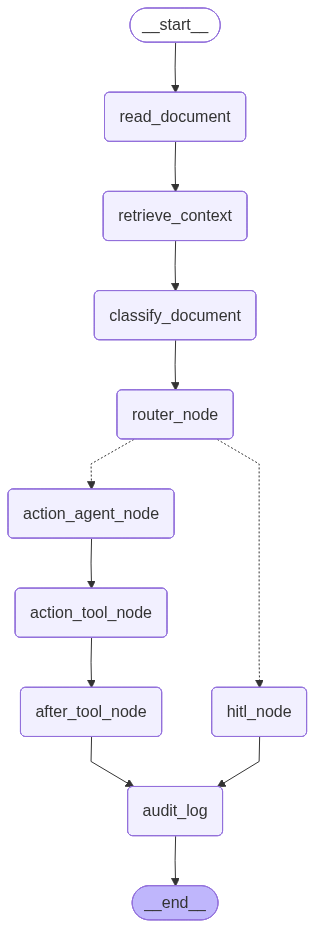

 Architecture diagram rendered above


In [178]:
print(" Rendering architecture diagram...")
try:
    png_bytes = app.get_graph().draw_mermaid_png()
    display(Image(png_bytes))
    print(" Architecture diagram rendered above")
except Exception as e:
    print(f"  PNG render failed ({e})")
    try:
        print("   Mermaid source (paste at https://mermaid.live):\n")
        print(app.get_graph().draw_mermaid())
    except:
        print("""
  read_document → retrieve_context → classify_document → router_node
                                                              ↙              ↘
                                                    action_agent_node     hitl_node
                                                          ↓               (interrupt)
                                                    action_tool_node          ↓
                                                          ↓                   ↓
                                                    after_tool_node           ↓
                                                          ↘                  ↙
                                                            audit_log → END
        """)

# Batch-Process ALL PDFs from Intake Folder

In [179]:
thread_registry : Dict[str, str] = {}
all_results     : List[dict]     = []
hitl_pending    : List[dict]     = []

def process_document(pdf_path: str) -> dict:
    """Run the full pipeline on one PDF. Returns final state or interrupt info."""
    name      = Path(pdf_path).name
    thread_id = f"doc_{name.replace('.pdf','').replace(' ','_')}_{int(time.time())}"
    thread_registry[name] = thread_id

    console.print("\n" + "═"*65)
    console.print(f"[bold]  {name}[/bold]  [dim]{thread_id}[/dim]")
    console.print("═"*65)

    initial: CeaseDesistState = {
        "messages"         : [],
        "document_path"    : pdf_path,
        "document_name"    : name,
        "raw_text"         : "",
        "processing_date"  : datetime.now().isoformat(),
        "rag_context"      : "",
        "classification"   : "",
        "confidence"       : 0.0,
        "explanation"      : "",
        "extracted_details": {},
        "action_taken"     : "",
        "hitl_result"      : None,
        "audit_entry"      : {},
        "error"            : None
    }

    config = {"configurable": {"thread_id": thread_id}}

    try:
        final = app.invoke(initial, config=config)

        if isinstance(final, dict) and "__interrupt__" in final:
            payload = final["__interrupt__"][0].value
            console.print(Panel(
                f"[bold yellow]⏸  PAUSED[/bold yellow]: {name}\n"
                f"LLM: {payload.get('llm_classification')} ({payload.get('confidence',0):.2f})\n"
                f"Reason: {payload.get('explanation','')[:200]}\n\n"
                f"[cyan]Resume in Cell 15 with thread_id='{thread_id}'[/cyan]",
                title="[bold yellow] HITL", border_style="yellow"
            ))
            return {"__interrupt__": True, "thread_id": thread_id,
                    "doc_name": name, "payload": payload}

        return final

    except Exception as e:
        if "interrupt" in str(type(e).__name__).lower() or "Interrupt" in str(e):
            return {"__interrupt__": True, "thread_id": thread_id, "doc_name": name}
        console.print(f"[red] {e}[/red]")
        return {"error": str(e), "document_name": name}


# ── Run all intake PDFs ────────────────────────────────────────────────
intake_pdfs = sorted(Path(CONFIG["intake_folder"]).glob("*.pdf"))

console.print(Panel(
    "\n".join(f"   {p.name}" for p in intake_pdfs),
    title=f"[bold] Processing {len(intake_pdfs)} documents from {CONFIG['intake_folder']}"
))

for p in intake_pdfs:
    result = process_document(str(p))
    (hitl_pending if result.get("__interrupt__") else all_results).append(result)

console.print(f"\n[bold]Done:[/bold] "
              f"[green]{len(all_results)} completed[/green]  "
              f"[yellow]{len(hitl_pending)} HITL pending[/yellow]")

╭───────────────────────────────  Processing 29 documents from /content/data/pdfs ────────────────────────────────╮
│    01_copyright_infringement_photography.pdf                                                                    │
│    02_trademark_infringement_tech.pdf                                                                           │
│    03_trade_secret_misappropriation.pdf                                                                         │
│    04_defamation_online_review.pdf                                                                              │
│    05_patent_infringement_medical_device.pdf                                                                    │
│    06_harassment_workplace.pdf                                                                                  │
│    07_software_license_violation.pdf                                                                            │
│    08_non_compete_violation.pdf                                                                                 │
│    09_copyright_infringement_music.pdf                                                                          │
│    10_breach_of_contract_nda.pdf                                                                                │
│    LOA2.pdf                                                                                                     │
│    LOA3.pdf                                                                                                     │
│    LOA4.pdf                                                                                                     │
│    LOA5.pdf                                                                                                     │
│    LOA6.pdf                                                                                                     │
│    LOA7.pdf                                                                                                     │
│    LOA8.pdf                                                                                                     │
│    LOA9.pdf                                                                                                     │
│    LoA1.pdf                                                                                                     │
│    bw_doc_1.pdf                                                                                                 │
│    bw_doc_2.pdf                                                                                                 │
│    bw_doc_3.pdf                                                                                                 │
│    bw_doc_4.pdf                                                                                                 │
│    bw_doc_5.pdf                                                                                                 │
│    notice_1.pdf                                                                                                 │
│    notice_2.pdf                                                                                                 │
│    notice_3.pdf                                                                                                 │
│    notice_4.pdf                                                                                                 │
│    notice_5.pdf                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

═════════════════════════════════════════════════════════════════

  01_copyright_infringement_photography.pdf  doc_01_copyright_infringement_photography_1774170069

═════════════════════════════════════════════════════════════════

[ReadDoc] 01_copyright_infringement_photography.pdf

...

═════════════════════════════════════════════════════════════════

[ReadDoc] LOA8.pdf

2 page(s), 4476 chars

ChromaDB search (history: 1 msgs)

KeyboardInterrupt: 

#HITL: interrupt + Command(resume)

In [ ]:
if hitl_pending:
    for item in hitl_pending:
        tid     = item["thread_id"]
        name    = item.get("doc_name", "unknown")
        payload = item.get("payload", {})

        console.print(Panel(
            f"[bold]Document  :[/bold] {name}\n"
            f"[bold]LLM said  :[/bold] [yellow]{payload.get('llm_classification','uncertain')}[/yellow] "
            f"({payload.get('confidence',0):.2f})\n"
            f"[bold]Reasoning :[/bold]\n{payload.get('explanation','')[:400]}\n"
            f"[bold]Sender    :[/bold] {payload.get('sender_name','?')}  "
            f"[bold]Account:[/bold] {payload.get('account_number','?')}\n"
            f"[bold]Preview   :[/bold][dim]{payload.get('document_preview','')[:350]}[/dim]",
            title="[bold yellow] HUMAN REVIEW", border_style="yellow"
        ))

        #   CHANGE THIS — options: "cease" | "irrelevant" | "skip"
        human_decision = "irrelevant"

        console.print(f"Decision: [yellow]{human_decision.upper()}[/yellow]")
        try:
            resumed = app.invoke(
                Command(resume=human_decision),
                config={"configurable": {"thread_id": tid}}
            )
            all_results.append(resumed)
            console.print(f"[green] Resumed: {name}[/green]")
        except Exception as e:
            console.print(f"[yellow]Resume note: {e}[/yellow]")
else:
    console.print("[green] No HITL items — all docs automated[/green]")

#Results Dashboard

In [ ]:
tbl = Table(title=" Classification Results",
            show_header=True, header_style="bold white on dark_blue", show_lines=True)
for col, w in [("#",3),("Document",30),("Classification",15),
               ("Confidence",14),("Msgs",6),("HITL",6),("Action",30)]:
    tbl.add_column(col, width=w)

for i, r in enumerate(all_results, 1):
    cls   = r.get("classification","unknown")
    color = CLASS_COLOR.get(cls,"white")
    conf  = r.get("confidence",0.0)
    tbl.add_row(
        str(i),
        r.get("document_name","?"),
        f"[{color}]{cls.upper()}[/{color}]",
        f"{conf:.2f} " + "█"*int(conf*8) + "░"*(8-int(conf*8)),
        str(len(list(r.get("messages",[])))),
        "✅" if r.get("hitl_result") else "—",
        r.get("action_taken","")[:28]
    )
console.print(tbl)

# Query DB / Archive / Audit / HITL Queue

In [ ]:
console.print("\n\n[bold red]  SQLITE — Cease Records[/bold red]")
conn  = sqlite3.connect(CONFIG["sqlite_db_path"])
db_df = pd.read_sql_query(
    "SELECT id,received_date,document_name,sender_name,account_number,"
    "ROUND(confidence,2) conf FROM cease_desist_requests ORDER BY id", conn)
conn.close()
print(db_df.to_string(index=False) if not db_df.empty else "  No records yet.")

console.print("\n\n[bold green] ARCHIVE CSV — Irrelevant[/bold green]")
ap = Path(CONFIG["archive_csv_path"])
print(pd.read_csv(ap).to_string(index=False) if ap.exists() else "  Not created yet.")

console.print("\n\n[bold cyan] AUDIT LOG[/bold cyan]")
lp = Path(CONFIG["audit_log_path"])
if lp.exists():
    df = pd.read_csv(lp)
    cols = ["document_name","classification","confidence",
            "action_taken","hitl_involved","message_count"]
    print(df[[c for c in cols if c in df.columns]].to_string(index=False))

console.print("\n\n[bold yellow] HITL QUEUE[/bold yellow]")
hp = Path(CONFIG["hitl_queue_path"])
print(pd.read_csv(hp).to_string(index=False) if hp.exists() else "  Empty.")

#Inspect Conversation Thread (add_messages in action)

In [ ]:
IDX = 0  # Change to inspect a different completed document

if all_results and IDX < len(all_results):
    r    = all_results[IDX]
    msgs = list(r.get("messages", []))
    console.print("\n----------Conversation Thread--------- \n",
        f"\n[bold]{r.get('document_name')}[/bold] — "
        f"[bold]{len(msgs)}[/bold] messages via [cyan]add_messages[/cyan] reducer \n",

   )
    STYLE = {"SystemMessage":("bold blue","SYSTEM "),
              "HumanMessage" :("bold green","HUMAN  "),
              "AIMessage"    :("bold magenta","AI     "),
              "ToolMessage"  :("bold cyan","TOOL   ")}
    for i, msg in enumerate(msgs, 1):
        col, lbl = STYLE.get(type(msg).__name__, ("white", "???    "))
        body = str(msg.content)[:130]
        console.print(f"  [{col}][{i:02d}] {lbl}[/{col}]: {body}")
        if hasattr(msg, "tool_calls") and msg.tool_calls:
            console.print(f"         [yellow]→ tool_calls: {[tc.get('name') for tc in msg.tool_calls]}[/yellow]")
else:
    print("No results yet.")

# FINAL SUMMARY: All Documents Categorised by Class


In [ ]:
categorised: Dict[str, List[dict]] = defaultdict(list)

for r in all_results:
    # Normalise: for HITL-resolved docs, use hitl_result as final classification
    if r.get("hitl_result") and r["hitl_result"] in [CEASE, IRRELEVANT]:
        final_cls = r["hitl_result"]
    elif r.get("hitl_result") == "skip":
        final_cls = UNCERTAIN   # Still uncertain (skipped by human)
    else:
        final_cls = r.get("classification", "unknown")

    categorised[final_cls].append({
        "document_name" : r.get("document_name", "?"),
        "confidence"    : round(r.get("confidence", 0.0), 3),
        "hitl_involved" : "yes" if r.get("hitl_result") else "no",
        "hitl_decision" : r.get("hitl_result", ""),
        "action_taken"  : r.get("action_taken", "none"),
        "explanation"   : r.get("explanation", "")[:120]
    })

# Add HITL-pending (not yet resolved) to uncertain
for item in hitl_pending:
    payload = item.get("payload", {})
    categorised[UNCERTAIN].append({
        "document_name" : item.get("doc_name", "?"),
        "confidence"    : round(payload.get("confidence", 0.0), 3),
        "hitl_involved" : "pending",
        "hitl_decision" : "awaiting_human",
        "action_taken"  : "queued_for_hitl_review",
        "explanation"   : payload.get("explanation", "")[:120]
    })

# ── Count summary ──────────────────────────────────────────────────────
summary_counts = {cls: len(categorised.get(cls,[])) for cls, _, _ in SECTION_ORDER}
total_docs = sum(summary_counts.values())

console.print(Panel(
    f"   Cease      : {summary_counts[CEASE]:3d} document(s)  → SQLite records\n"
    f"   Uncertain  : {summary_counts[UNCERTAIN]:3d} document(s)  → HITL queue\n"
    f"   Irrelevant : {summary_counts[IRRELEVANT]:3d} document(s)  → CSV archive\n"
    f"  ─────────────────────────────\n"
    f"  TOTAL                 : {total_docs:3d} document(s)",
    title="[bold] Category Totals"
))

# ── Export summary to CSV ──────────────────────────────────────────────
summary_rows = []
for cls, _, _ in SECTION_ORDER:
    for doc in categorised.get(cls, []):
        summary_rows.append({
            "document_name" : doc["document_name"],
            "category"      : cls,
            "confidence"    : doc["confidence"],
            "hitl_involved" : doc["hitl_involved"],
            "hitl_decision" : doc["hitl_decision"],
            "action_taken"  : doc["action_taken"],
            "explanation"   : doc["explanation"]
        })

if summary_rows:
    summary_df = pd.DataFrame(summary_rows)
    summary_df.to_csv(CONFIG["summary_report_path"], index=False)
    console.print(f"\n Summary exported → {CONFIG['summary_report_path']}")
    print()
    print(summary_df.to_string(index=False))